# Business Revenue Forecasting - Model Tuning

## Objective
Keep this notebook close to the DS/ML template while reusing the existing project helpers.
Build a simple regression model with the business features and compare it against the baseline signals from notebook 02.


In [1]:
import sys
sys.path.append("..")

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from src.notebook_common import pd, np, plt, sns
from src.notebook_common import csv_path, target_col, time_col, feature_cols, load_df

output_csv = None


In [2]:
df = load_df()

print("csv_path:", csv_path)
print(df.shape)
display(df.head())


csv_path: ../data/row/business_revenue_forecasting.csv
(36, 6)


,date,revenue,num_active_users,marketing_spend,discount_rate,new_signups
0,2023-01-01,8200000,12000,1200000,0.10,900
1,2023-02-01,8000000,11800,1100000,0.12,850
2,2023-03-01,8500000,12300,1300000,0.09,980
3,2023-04-01,8900000,12750,1350000,0.08,1020
4,2023-05-01,9100000,13000,1400000,0.08,1080


In [3]:
model_df = df[[time_col, target_col] + feature_cols].copy()
model_df["lag_1"] = model_df[target_col].shift(1)
model_df["rolling_mean_3"] = model_df[target_col].shift(1).rolling(3).mean()
model_df = model_df.dropna().reset_index(drop=True)

display(model_df.head())


,date,revenue,num_active_users,marketing_spend,discount_rate,new_signups,lag_1,rolling_mean_3
0,2023-04-01,8900000,12750,1350000,0.08,1020,8500000.0,8.233333e+06
1,2023-05-01,9100000,13000,1400000,0.08,1080,8900000.0,8.466667e+06
2,2023-06-01,9400000,13450,1450000,0.07,1120,9100000.0,8.833333e+06
3,2023-07-01,9800000,14000,1600000,0.08,1250,9400000.0,9.133333e+06
4,2023-08-01,10100000,14400,1550000,0.09,1210,9800000.0,9.433333e+06


In [4]:
model_feature_cols = [c for c in model_df.columns if c not in [target_col, time_col]]

X = model_df[model_feature_cols].copy()
y = model_df[target_col].copy()

X["time_index"] = range(len(X))
X["year"] = model_df[time_col].dt.year
X["month"] = model_df[time_col].dt.month

X = pd.get_dummies(X, dummy_na=True)
X = X.fillna(0)

print(X.shape, y.shape)
display(X.head())


(33, 9) (33,)


,num_active_users,marketing_spend,discount_rate,new_signups,lag_1,rolling_mean_3,time_index,year,month
0,12750,1350000,0.08,1020,8500000.0,8.233333e+06,0,2023,4
1,13000,1400000,0.08,1080,8900000.0,8.466667e+06,1,2023,5
2,13450,1450000,0.07,1120,9100000.0,8.833333e+06,2,2023,6
3,14000,1600000,0.08,1250,9400000.0,9.133333e+06,3,2023,7
4,14400,1550000,0.09,1210,9800000.0,9.433333e+06,4,2023,8


In [5]:
split_idx = int(len(X) * 0.8)
X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()
test_df = model_df.iloc[split_idx:].reset_index(drop=True).copy()

print("train shape:", X_train.shape, y_train.shape)
print("test shape:", X_test.shape, y_test.shape)
display(test_df)


train shape: (26, 9) (26,)
test shape: (7, 9) (7,)


,date,revenue,num_active_users,marketing_spend,discount_rate,new_signups,lag_1,rolling_mean_3
0,2025-06-01,18400000,26100,3150000,0.08,2230,17900000.0,1.730000e+07
1,2025-07-01,18900000,26800,3300000,0.09,2340,18400000.0,1.786667e+07
2,2025-08-01,19200000,27250,3250000,0.10,2290,18900000.0,1.840000e+07
3,2025-09-01,19900000,28100,3400000,0.08,2410,19200000.0,1.883333e+07
4,2025-10-01,20400000,28950,3500000,0.09,2490,19900000.0,1.933333e+07
5,2025-11-01,21800000,30400,4100000,0.18,2980,20400000.0,1.983333e+07
6,2025-12-01,22900000,31800,4350000,0.20,3220,21800000.0,2.070000e+07


In [6]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [7]:
def calc_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

results = pd.DataFrame(
    [
        {
            "model": "linear_regression",
            "mae": mean_absolute_error(y_test, y_pred),
            "rmse": calc_rmse(y_test, y_pred),
            "r2": r2_score(y_test, y_pred),
        },
        {
            "model": "lag_1",
            "mae": mean_absolute_error(y_test, test_df["lag_1"]),
            "rmse": calc_rmse(y_test, test_df["lag_1"]),
            "r2": r2_score(y_test, test_df["lag_1"]),
        },
        {
            "model": "rolling_mean_3",
            "mae": mean_absolute_error(y_test, test_df["rolling_mean_3"]),
            "rmse": calc_rmse(y_test, test_df["rolling_mean_3"]),
            "r2": r2_score(y_test, test_df["rolling_mean_3"]),
        },
    ]
)

display(results.sort_values("rmse"))


,model,mae,rmse,r2
0,linear_regression,1.419391e+05,1.541072e+05,0.989550
1,lag_1,7.142857e+05,8.017837e+05,0.717134
2,rolling_mean_3,1.319048e+06,1.409210e+06,0.126187


In [8]:
pred_df = pd.DataFrame(
    {
        "row_id": X_test.index,
        "date": test_df[time_col],
        "y_true": y_test.to_numpy(),
        "y_pred": y_pred,
        "lag_1": test_df["lag_1"].to_numpy(),
        "rolling_mean_3": test_df["rolling_mean_3"].to_numpy(),
    }
)

if output_csv is not None:
    pred_df.to_csv(output_csv, index=False)
    print("saved:", output_csv)

display(pred_df)


,row_id,date,y_true,y_pred,lag_1,rolling_mean_3
0,26,2025-06-01,18400000,1.850025e+07,17900000.0,1.730000e+07
1,27,2025-07-01,18900000,1.905372e+07,18400000.0,1.786667e+07
2,28,2025-08-01,19200000,1.926533e+07,18900000.0,1.840000e+07
3,29,2025-09-01,19900000,1.996508e+07,19200000.0,1.883333e+07
4,30,2025-10-01,20400000,2.059790e+07,19900000.0,1.933333e+07
5,31,2025-11-01,21800000,2.199317e+07,20400000.0,1.983333e+07
6,32,2025-12-01,22900000,2.311814e+07,21800000.0,2.070000e+07


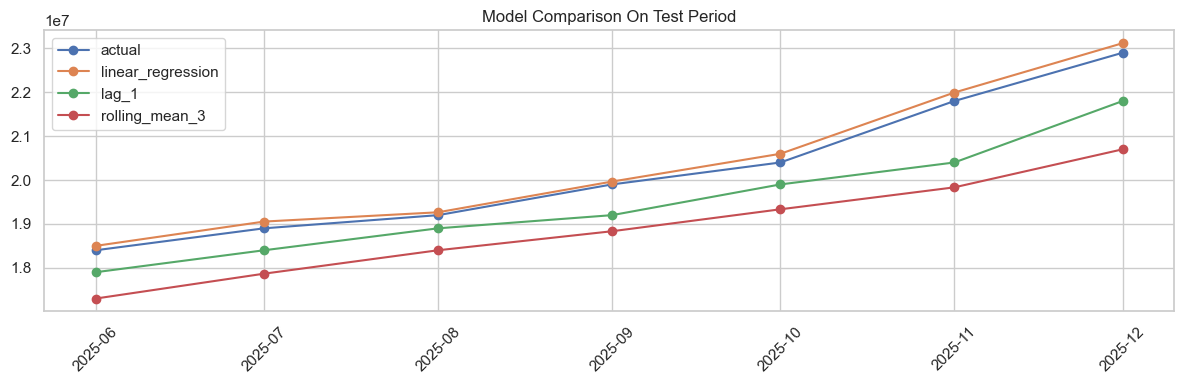

In [9]:
plt.figure(figsize=(12, 4))
plt.plot(pred_df["date"], pred_df["y_true"], marker="o", label="actual")
plt.plot(pred_df["date"], pred_df["y_pred"], marker="o", label="linear_regression")
plt.plot(pred_df["date"], pred_df["lag_1"], marker="o", label="lag_1")
plt.plot(pred_df["date"], pred_df["rolling_mean_3"], marker="o", label="rolling_mean_3")
plt.title("Model Comparison On Test Period")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


## Notes

- This notebook keeps the workflow intentionally simple and template-first.
- The model uses the business features from `notebook_common.py` plus simple lag and calendar features.
- Use the result table to compare the simple regression model against the baseline signals from notebook 02.
